# Chapter 3. 비지도 학습과 데이터 전처리

In [35]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
import IPython
import sklearn
#import mglearn

print('Python 버전:', sys.version)
print('numpy 버전:', np.__version__)
print('pandas 버전:', pd.__version__)
print('matplotlib 버전:', matplotlib.__version__)

print('SciFy 버전:', sp.__version__)
print('IPython 버전:', IPython.__version__)
print('scikit-learn 버전:', sklearn.__version__)

from sklearn.model_selection import train_test_split
#plt.rc('font', family="Apple SD Gothic Neo")

Python 버전: 3.10.13 (main, Sep 11 2023, 13:21:10) [GCC 11.2.0]
numpy 버전: 1.25.2
pandas 버전: 2.1.1
matplotlib 버전: 3.8.0
SciFy 버전: 1.11.3
IPython 버전: 8.15.0
scikit-learn 버전: 1.3.0


## 3.4 차원 축소, 특성 추출, 매니폴드 학습
- 비지도 학습을 사용해 데이터를 변환하는 이유
> - 시각화하거나, 데이터를 압축하거나, 지도학습에 사용하기 위해 정보가 더 잘 드러나는 표현을 찾는 목적임
> - **주성분 분석 (Principal Component Analysis, PCA)**
> - **비음수 행렬 분해 (Non-negative Matrix Factorization, NMF) : 특성 추출에 널리 사용**
> - **t-SNE (t-distributed Stochastic Neighbor Embedding) : 2차원 산점도를 활용해 시각화 용도로 널리 사용**

### 3.4.1 주성분 분석(PCA)
- **특성들이 통계적으로 상관관계가 없도록 데이터셋을 회전시키는 기술**
- **회전한 뒤에 데이터를 설명하는 데 얼마나 중요하냐에 따라 종종 새로운 특성 중 일부만 선택**
- PCA의 단점은 주성분을 해석하기가 쉽지 않다는 점, **주성분은 원본 데이터에 있는 어떤 방향에 대응하는 여러 특성이 조합된 형태임**
- **PCA 객체가 학습될 때 components_속성에 주성분이 저장, 각 행은 주성분 하나씩을 나타내며 중요도에 따라 정렬되어 있음, 열은 원본 데이터의 특성에 대응하는 값임**
- 특성의 스케일이 서로 다르면 올바른 주성분 방향을 찾을 수 없으니 **PCA를 사용할 때는 표준값으로 바꿔야 함**
- **PCA 적용 방법**
> - PCA 객체를 생성하고, fit 메서드를 호출해 주성분을 찾음
> - transform 메서드를 호출해 데이터를 회전 시키고 차원을 축소함
> - **기본값일 때 PCA는 데이터를 회전(그리고 이동)만 시키고 모든 주성분을 유지 -> 차원을 줄이려면 PCA 객체를 생성할 때 얼마나 많은 성분을 유지할 지 설정해야함**

In [29]:
# 예시
mglearn.plots.plot_pca_illustration()

NameError: name 'mglearn' is not defined

1. 먼저 '성분1'로 표기되는 **분산이 가장 큰 방향을 찾음(특성1과 특성2 정보 모두 포함한 방향임) -> 데이터에서 가장 많은 정보를 담고 있는 방향**
2. 첫번째 방향과 직각인 방향 중에서 가장 많은 정보를 담은 방향 탐색 -> **서로 독립된 성분을 구성함 -> 데이터에 있는 주된 분산의 방향인 주성분들을 구성함**
3. **일반적으로 원본 특성 개수 만큼의 주성분이 있음**, 특정 개수보다 많은 주성분을 설정하거나 지정된 주성분보다 샘플 갯수가 적을 경우 에러 출력
4. PCA는 주성분 중 일부만 남기는 차원축소 용도로 사용 가능 -> 위 예제에서는 주방향 1번만 유지 -> **단순히 원본 특성 중 하나만 남기는 개념이 아님을 주의**
5. **PCA 차원 축소는 데이터에서 노이즈를 제거하거나 주성분에서 유지되는 정보를 시각화하는데 종종 사용됨**

- **작동 추가 설명**
> - **PCA에서는 특잇값 분해(SVD) 방식**을 사용해 주성분을 찾음
> - 먼저 fit 메서드에서 Scify의 linalg.svd 함수를 이용해 U, s, V 배열을 구함
> - **transform 메서드에서 입력 데이터와 주성분 V 행렬의 전치행렬을 곱해 변환된 데이터를 구함**, 해당값은 U와 s를 곱해서도 얻을 수 있음
> - **fit_transform 메서드에서는 U와 s를 사용해 변환된 데이터를 계산하며, 차원이 많은 데이터에서 몇 개의 주성분만 고를 경우 성능이 조금 더 높게 도출됨**

#### <U>*사례: PCA를 적용해 유방암 데이터셋 시각화하기*</U>

NameError: name 'mglearn' is not defined

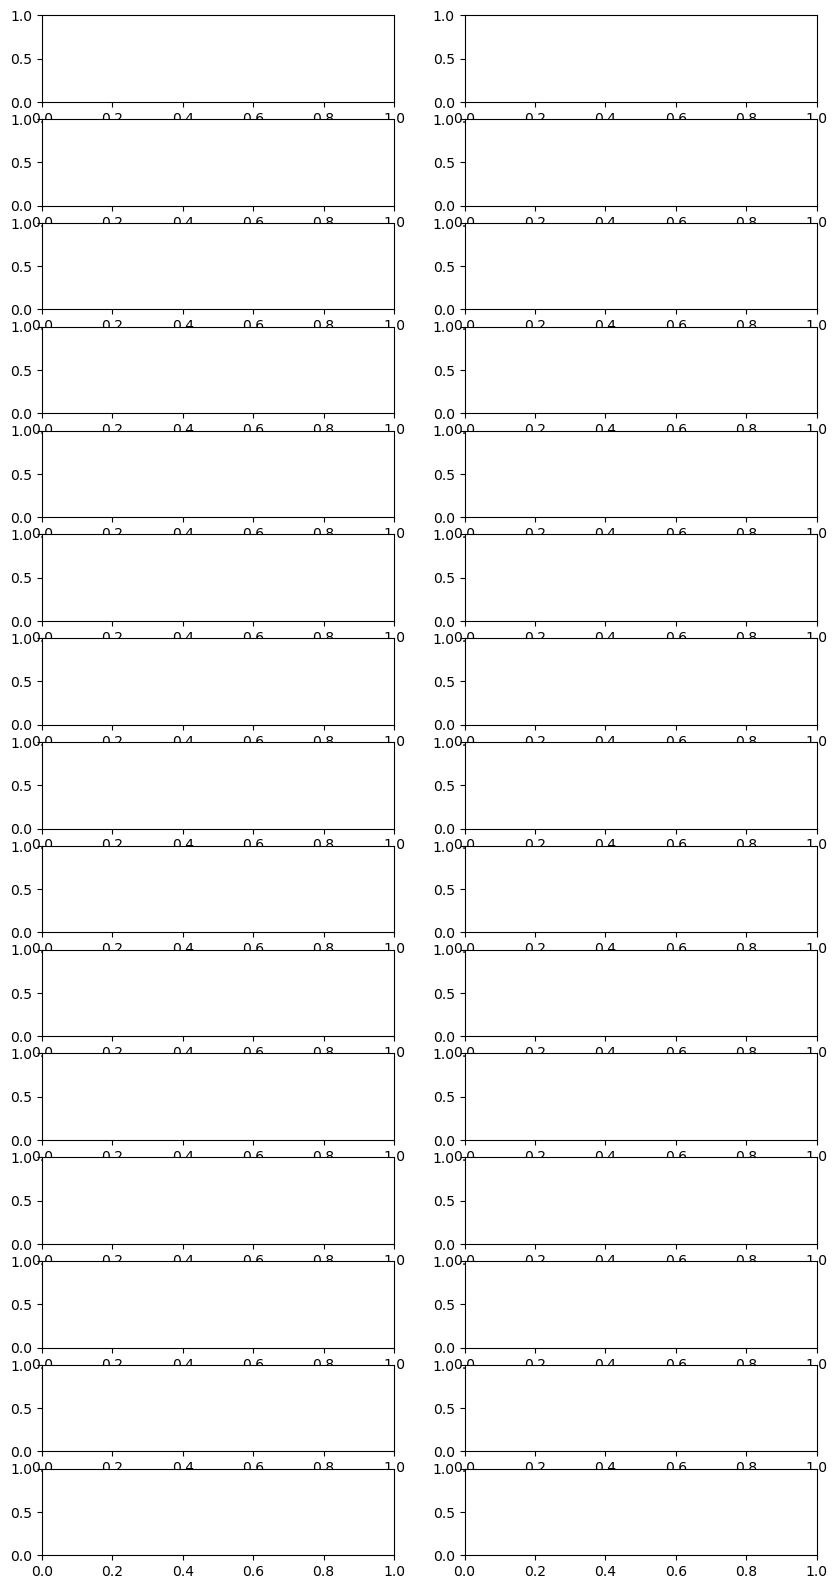

In [31]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

fig, axes = plt.subplots(15,2, figsize=(10,20))
malignant = cancer.data[cancer.target == 0]
benign = cancer.data[cancer.target == 1]

ax = axes.ravel()

for i in range(30):
    _, bins = np.histogram(cancer.data[:,i], bins=50)
    ax[i].hist(malignant[:,i], bins=bins, color=mglearn.cm3(0), alpha=0.5)
    ax[i].hist(benign[:,i], bins=bins, color=mglearn.cm3(2), alpha=0.5)
    ax[i].set_title(cancer.feature_names[i])
    ax[i].set_yticks(())

ax[0].set_xlabel('Feature magnitude')
ax[0].set_ylabel('Frequency')
ax[0].legend(['malignant','benign'], loc='best')
fig.tight_layout()

- 위 그래프들을 통해 어떤 특성이 악성/양성 종양 구분에 유용할지 예측할 수 있음
- "smoothness error" vs "worst concave points"
- **하지만, 특성간의 상호작용이나 이 상호작용이 클래스와 어떤 관련이 있는지 알수 없음
-> PCA를 사용하면 주요 상호작용을 찾을 수 있음**

> - 처음 두 개의 주성분을 찾아 2차원 공간에 하나의 산점도로 데이터 시각화

In [33]:
# PCA를 적용하기 전에 StandardScaler를 사용해 각 특성의 분산이 1이 되도록 데이터의 스케일 조정
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(cancer.data)
X_scaled = scaler.transform(cancer.data)

In [59]:
# PCA + 차원축소 수행
from sklearn.decomposition import PCA
# 데이터의 처음 두 개 주성분만 유지
pca = PCA(n_components=2)
# 유방암 데이터로 PCA 모델의 주성분 찾기
pca.fit(X_scaled)

# 처음 두 개의 주성분을 사용해 데이터를 변환
X_pca = pca.transform(X_scaled)
print("원본 데이터 형태:", str(X_scaled.shape))
print("축소된 데이터 형태:", str(X_pca.shape))

원본 데이터 형태: (569, 30)
축소된 데이터 형태: (569, 2)


Text(0, 0.5, '2nd Principal component')

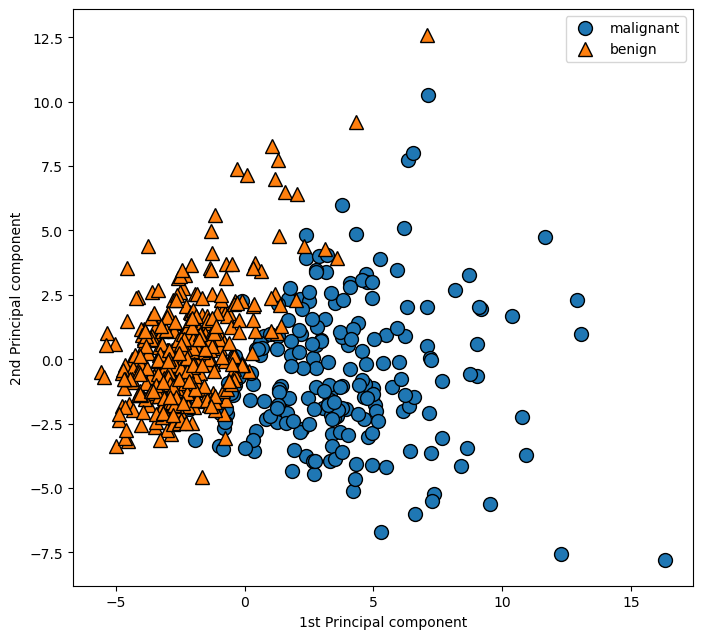

In [60]:
# 클래스를 색깔로 구분하여 처음 두 개의 주성분을 그래프로 표현
plt.figure(figsize=(8,8))
mglearn.discrete_scatter(X_pca[:,0], X_pca[:,1], cancer.target)
plt.legend(['malignant', 'benign'], loc='best')
plt.gca().set_aspect('equal')
plt.xlabel('1st Principal component')
plt.ylabel('2nd Principal component')

PCA 주성분 형태: (2, 30)
PCA 주성분: [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


Text(0, 0.5, 'Principal Components')

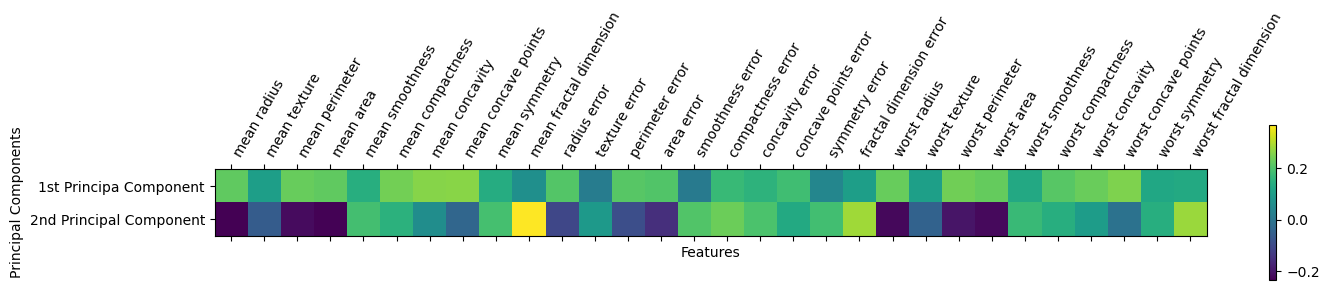

In [61]:
# 주성분 분석
print('PCA 주성분 형태:', pca.components_.shape)
print('PCA 주성분:', pca.components_)

# 위 값을 heatmap으로 시각화하면 이해하기 보다 용이
plt.matshow(pca.components_, cmap='viridis')
plt.colorbar()
plt.xticks(range(len(cancer.feature_names)), cancer.feature_names, rotation=60, ha='left')
plt.yticks([0,1], ['1st Principa Component', '2nd Principal Component'])
plt.xlabel('Features')
plt.ylabel('Principal Components')

#### <U>*사례: 고유얼굴(eigenface) 특성 추출*</U>
- PCA는 특성 추출에 이용 가능 : 원본 데이터 표현보다 분석하기에 더 적합한 표현을 찾는 과정
- 이미지를 다루는 응용에서 특성 추출이 도움이 됨, RGB를 가지는 픽셀이 함께 모여 있을 때 더 큰 의미를 가짐

- **LFW 데이터셋 검토**|

In [4]:
from sklearn.datasets import fetch_lfw_people
people = fetch_lfw_people(min_faces_per_person = 20, resize=0.7)

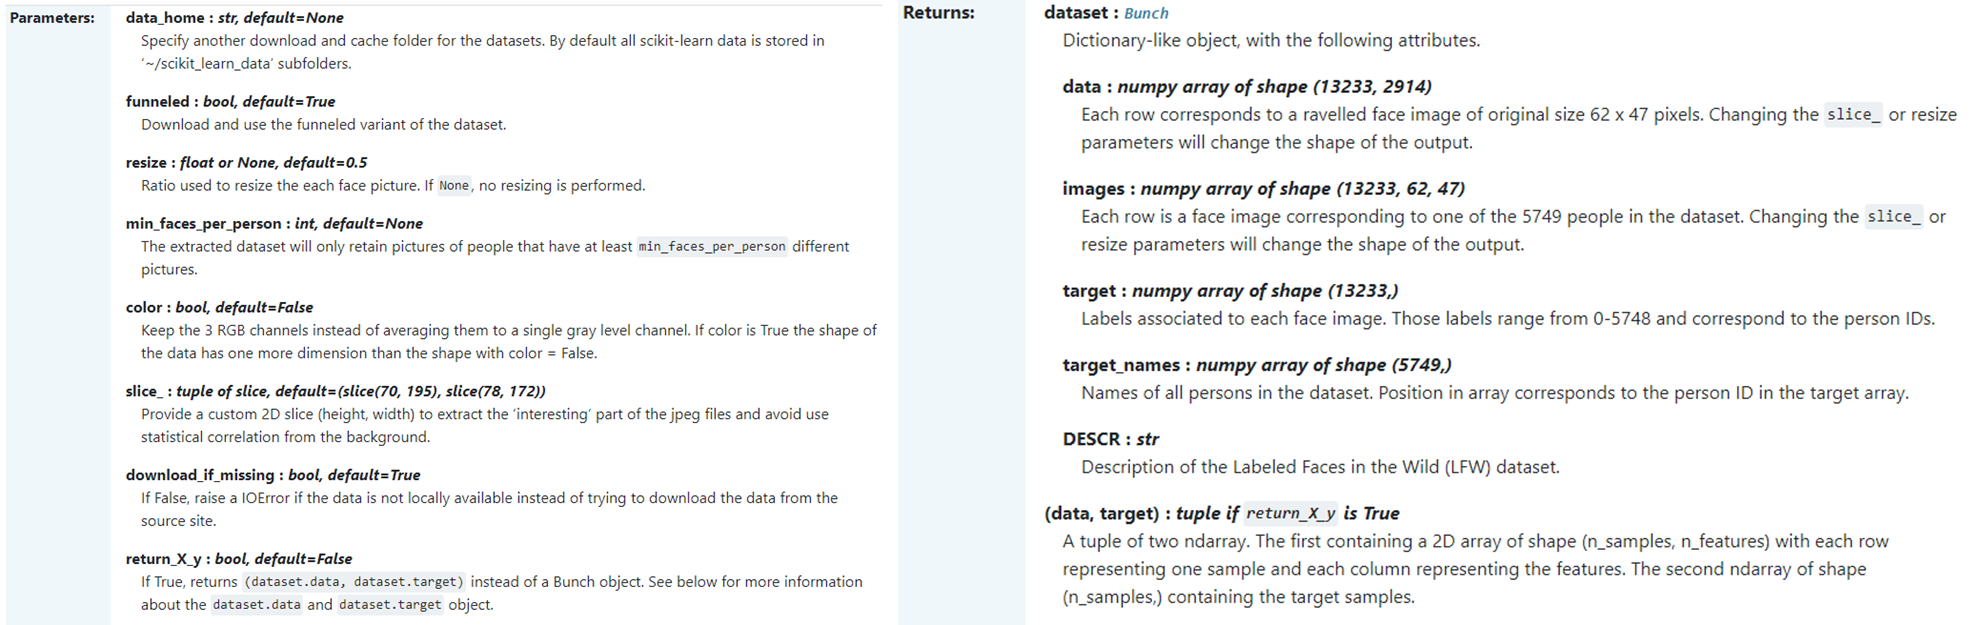

- ***min_faces_per_person = 20* 조건으로 인해 기존 original 데이터와 다른 크기의 데이터 생섬됨**
> - **62명 사람들의 3023개의 사진 데이터**
> - **각 사진의 픽셀은 87 x 65 = 5665임**

In [5]:
print('data', people.data.shape)
print('images', people.images.shape)
print('target', people.target.shape) # 사람 ID에 해당
print('target_names', people.target_names.shape) # 사람 이름 모음, 알파벳 순서임

data (3023, 5655)
images (3023, 87, 65)
target (3023,)
target_names (62,)


In [6]:
print(people.target)
print(people.target_names[[61,25,9]])

[61 25  9 ... 14 15 14]
['Winona Ryder' 'Jean Chretien' 'Carlos Menem']


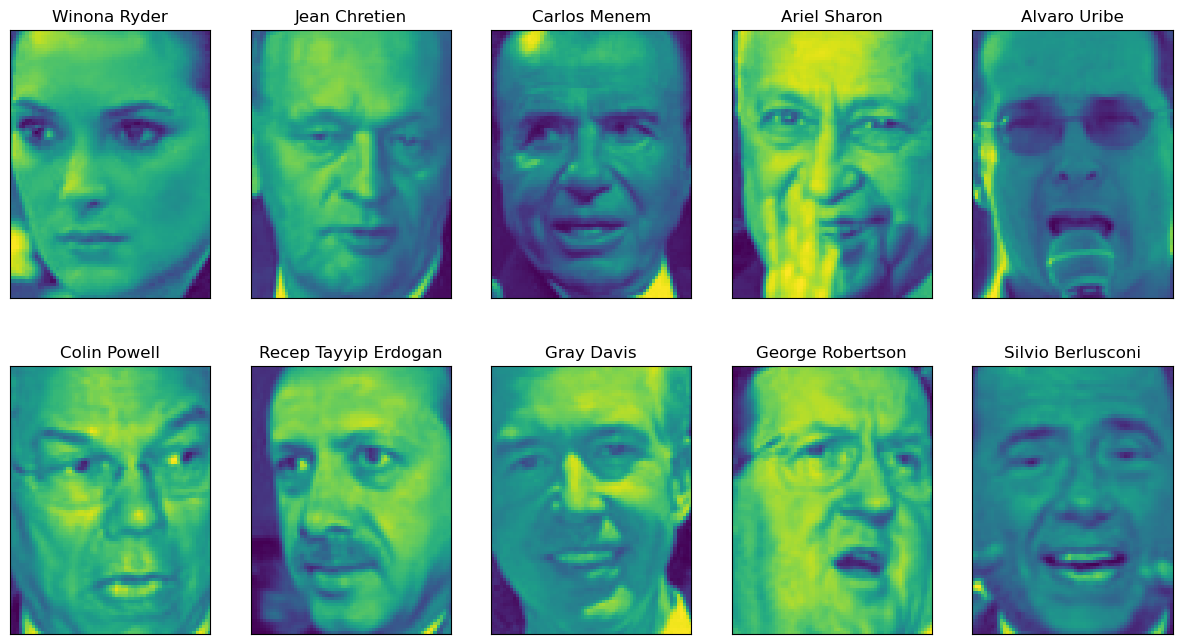

In [7]:
fig, axes = plt.subplots(2,5, figsize=(15,8), subplot_kw={'xticks':(), 'yticks':()})
for target, image, ax in zip(people.target, people.images, axes.ravel()):
    ax.imshow(image)
    ax.set_title(people.target_names[target])

In [8]:
# 각 타깃이 나타난 횟수 계산
counts = np.bincount(people.target)
# 타깃별 이름과 횟수 출력
for i, (count, name) in enumerate(zip(counts, people.target_names)):
    print("{0:25}{1:3}".format(name, count), end='     ')
    if (i+1) % 3 == 0:
        print()

Alejandro Toledo          39     Alvaro Uribe              35     Amelie Mauresmo           21     
Andre Agassi              36     Angelina Jolie            20     Ariel Sharon              77     
Arnold Schwarzenegger     42     Atal Bihari Vajpayee      24     Bill Clinton              29     
Carlos Menem              21     Colin Powell             236     David Beckham             31     
Donald Rumsfeld          121     George Robertson          22     George W Bush            530     
Gerhard Schroeder        109     Gloria Macapagal Arroyo   44     Gray Davis                26     
Guillermo Coria           30     Hamid Karzai              22     Hans Blix                 39     
Hugo Chavez               71     Igor Ivanov               20     Jack Straw                28     
Jacques Chirac            52     Jean Chretien             55     Jennifer Aniston          21     
Jennifer Capriati         42     Jennifer Lopez            21     Jeremy Greenstock         24     


- 조지 부시와 콜린 파월의 이미지가 상대적으로 너무 많음 -> **데이터셋의 편중을 없애기 위해 사람마다 50개의 이미지만 선택**

In [9]:
mask = np.zeros(people.target.shape, dtype=bool)
for target in np.unique(people.target):
    mask[np.where(people.target==target)[0][:50]] = 1

X_people = people.data[mask]
y_people = people.target[mask]

# 0-255 사이의 흑백 이미지의 픽셀 값을 0-1 스케일로 조정
# MinMaxScaler를 적용하는 것과 거의 같은 효과

X_people = X_people/255
print(X_people.shape)
print(y_people.shape)

(2063, 5655)
(2063,)


> - 얼굴인식은 통상 새로운 얼굴 이미지가 데이터베이스에 있는 기존 얼굴 중 하나에 속하는지 찾는 작업
> - 각 사람을 서로 다른 클래스로 구분하는 분류기를 만들 수 있지만 클래스별(사람별) 훈련데이터가 너무 적고, 매번 대규모 모델을 훈련시키기가 불가능
> - 간단한 방법으로 **분류하려는 얼굴과 가장 비슷한 얼굴 이미지를 찾는 1-최근접 이웃 분류기 사용 가능**
> - 해당 분류기는 원칙적으로 클래스마다 하나의 훈련 샘플을 사용

In [10]:
from sklearn.neighbors import KNeighborsClassifier

# 데이터를 훈련 세트와 테스트 세트로 나눔
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_people, y_people, stratify=y_people, random_state=0)

# 이웃 개수를 한 개로 하여 KNeighborsClassifier 모델 생성
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
print('1-최근접 이웃의 테스트 세트 점수: {:.2f}'.format(knn.score(X_test, y_test)))

1-최근접 이웃의 테스트 세트 점수: 0.22


> - **위 모델 성능을 올리기 위해 PCA 적용 검토** : 픽셀을 있는 그대로 비교하는 방식으로는 얼굴의 특징을 잡아내기가 어려움
>> - **PCA의 화이트닝(whitening) 옵션을 사용해** 주성분의 스케일이 같아지도록 조정하는 방안을 추가로 적용
>> - **이는 화이트닝 옵션 없이 주성분으로 변환한 후에 StandardScaler를 적용하는 것과 같은 효과임**

In [11]:
from sklearn.decomposition import PCA

# 100개의 주성분 추출
pca = PCA(n_components=100, whiten=True, random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

X_train_pca.shape # 특성 수 5655 -> 주성분 100으로 감소

(1547, 100)

In [12]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca, y_train)
print('테스트 세트 정확도: {:.2f}'.format(knn.score(X_test_pca, y_test)))

테스트 세트 정확도: 0.30


> - 몇 개의 주성분 확인

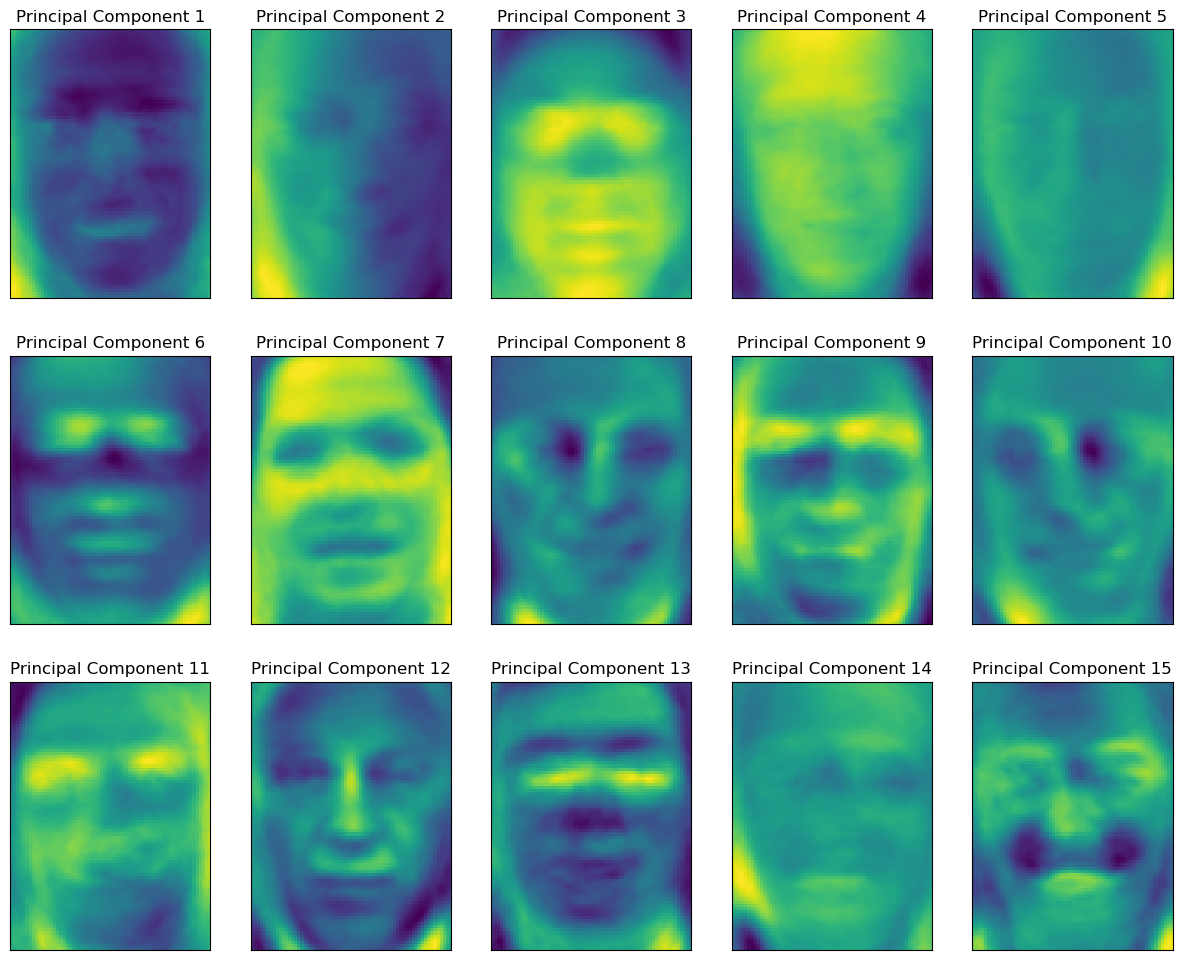

In [13]:
image_shape = people.images[0].shape

fig, axes = plt.subplots(3,5, figsize=(15,12), subplot_kw={'xticks':(), 'yticks':()})
for i, (component, ax) in enumerate(zip(pca.components_, axes.ravel())):
    ax.imshow(component.reshape(image_shape), cmap='viridis')
    ax.set_title('Principal Component {}'.format((i+1)))

#### <U>*설명된 분산의 비율*</U>
- 각 주성분은 원본 데이터셋의 한 방향이므로 **각 주성분이 얼만큼의 분산을 표현하는지 비교 가능** 
- 이를 **"설명된 분산의 비율"이라고 하며, *explained_variance_ratio_ 속성* 으로 제공**

In [14]:
np.sum(pca.explained_variance_ratio_)

0.89798146

- 100개의 주성분으로 약 89%의 표현 가능 분산 확보 가능

> - **적절한 주성분 개수를 찾으려면 설명된 분산을 누적한 그래프가 도움이 됨**, ~ 기여도 누적

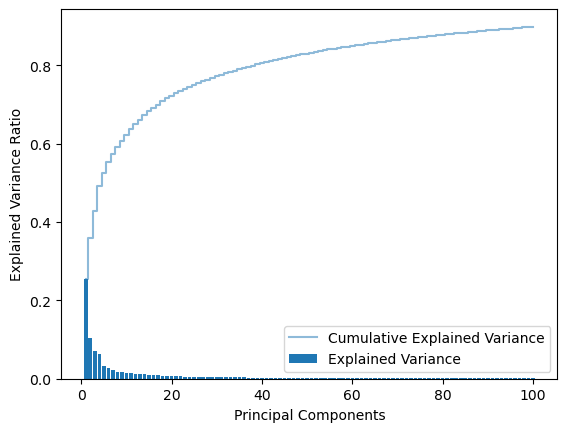

In [18]:
plt.bar(range(1,101), pca.explained_variance_ratio_, align='center', label='Explained Variance')
plt.step(range(1,101), np.cumsum(pca.explained_variance_ratio_), alpha=0.5, where='mid', label='Cumulative Explained Variance')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.show()

- 30번째 주성분 이후에는 설명된 분산이 크게 감소, 40개 정도만 선택하더라도 약 80%의 분산을 표현할 수 있음

> - PCA 클래스의 n_component 매개변수에는 주성분 개수 대시 누적 분산의 비율을 0-1 사이 실수로 지정 가능함
> - **아래는 80% 누적 분산 비율에 해당하는 주성분 개수를 찾도록 지정**하는 예임
> - **찾은 주성분 개수는 *n_components_* 속성에 저장**

In [21]:
pca = PCA(n_components=0.8, whiten=True, random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

knn.fit(X_train_pca, y_train)
print('테스트 세트 정확도: {:.2f}'.format(knn.score(X_test_pca, y_test)))
print('주성분 개수: ', pca.n_components_)

테스트 세트 정확도: 0.29
주성분 개수:  39


### 3.4.3 t-SNE를 이용한 매니폴드 학습
- 데이터를 산점도로 시각화할 수 있다는 이점 때문에 PCA가 종종 데이터 변환에 가장 먼저 시도 되지만 알고리즘의 회전하고 방향을 제거하는 태생상 유용성이 떨어지는 경우가 발생
- **매니폴드 학습(manifold learning)이라고 하는 시각화 알고리즘들은 훨씬 복잡한 매핑을 만들어 더 나은 시각화를 제공**
> - 시각화가 목적이라 3개 이상의 특성을 뽑는 경우가 거의 없음
> - 데이터 포인트 사이의 거리를 가장 잘 보존하는 2차원 표현을 탐색, 각 데이터 포인트를 2차원에 무작위로 표현한 후 원본 특성 공간에서 가까운 포인트는 가깝게, 멀리 떨어진 포인트는 멀어지게 만듦 -> 이웃  데이터 포인트에 대한 정보를 보존하려고 노력
> - **훈련 데이터를 새로운 표현으로 변환시키지만 새로운 데이터에는 적용하지 못함**
> - **테스트 세트에는 적용 불가, 탐색적 데이터 분석에 유용하지만 지도학습용으로는 거의 사용하지 않음**
- **매개변수**
> - ***perplexity* 값(기본 30)이 크면 더 많은 이웃을 포함하며 작은 그룹은 무시됨**
> - 보통 데이터셋이 클 경우 *perplexity* 값도 커야하며, 보통 5-50 사이의 값을 지정
> - TSNE 모델은 초기 과장(early exaggeration) 단계와 최적화 단계를 거침, ***early_exaggeration* 매개변수는 초기 과장 단계에서 원본 공간의 클러스터들이 얼마나 멀게 2차원에 나타낼 수 있는지 정함(기본 12)**

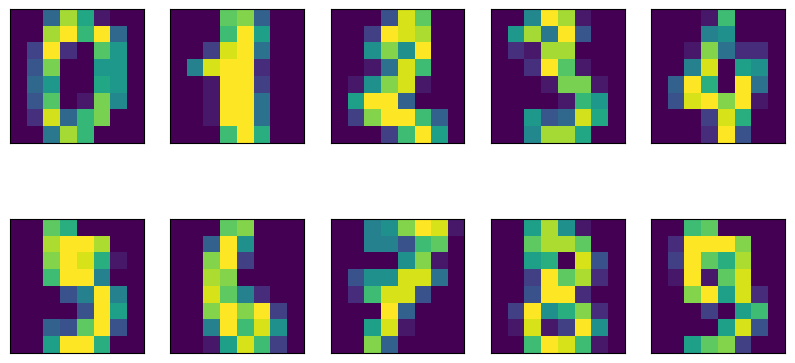

In [22]:
# 손글씨 숫자 데이터셋 활용
from sklearn.datasets import load_digits
digits = load_digits()

fig, axes = plt.subplots(2,5, figsize=(10,5), subplot_kw={'xticks':(), 'yticks':()})
for ax, img in zip(axes.ravel(), digits.images):
    ax.imshow(img)

Text(0, 0.5, '2nd Principal Component')

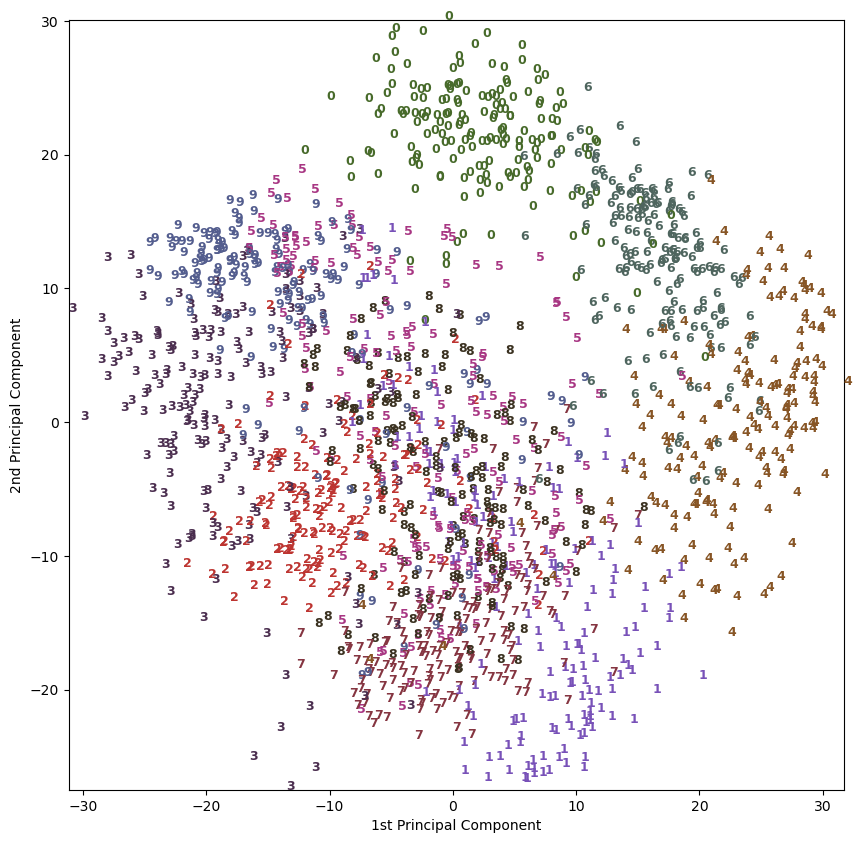

In [32]:
# PCA를 사용해 데이터를 2차원으로 축소해 시각화
# 처음 두 개의 주성분을 이용해 그래프를 그리고 각 샘플을 해당하는 클래스의 숫자로 나타냄

# PCA 모델 생성
pca = PCA(n_components=2)
pca.fit(digits.data)
# 처음 두 개의 주성분으로 숫자 데이터를 변환
digits_pca = pca.transform(digits.data)
colors = ['#476A2A', '#7851B8', '#BD3430', '#4A2D4E', '#875525', '#A83683', '#4E655E', '#853541', '#3A3120', '#535D8E']
plt.figure(figsize=(10,10))
plt.xlim(digits_pca[:,0].min(), digits_pca[:,0].max())
plt.ylim(digits_pca[:,1].min(), digits_pca[:,1].max())

for i in range(len(digits.data)):
    # 숫자 텍스트를 이용해 산점도를 그림
    plt.text(digits_pca[i,0], digits_pca[i,1], str(digits.target[i]),
             color = colors[digits.target[i]], fontdict={'weight':'bold', 'size':9})

plt.xlabel('1st Principal Component')
plt.ylabel('2nd Principal Component')

In [33]:
# 같은 데이터셋에 t-SNE를 적용하여 결과 비교
from sklearn.manifold import TSNE
tsne = TSNE(random_state=42)

# TSNE에는 transform 메서드가 없으므로 대신 fit_transform을 사용
digits_tsne = tsne.fit_transform(digits.data)

Text(0, 0.5, 't-SNE Feature 1')

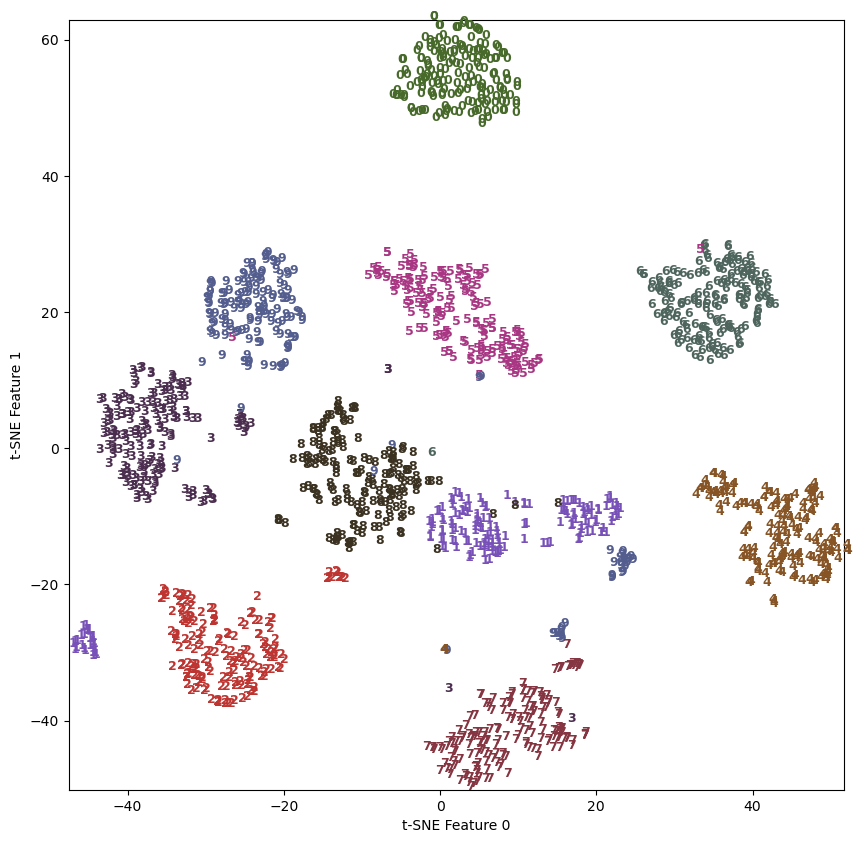

In [34]:
plt.figure(figsize=(10,10))
plt.xlim(digits_tsne[:,0].min(), digits_tsne[:,0].max())
plt.ylim(digits_tsne[:,1].min(), digits_tsne[:,1].max())

for i in range(len(digits.data)):
    # 숫자 텍스트를 이용해 산점도를 그림
    plt.text(digits_tsne[i,0], digits_tsne[i,1], str(digits.target[i]),
             color = colors[digits.target[i]], fontdict={'weight':'bold', 'size':9})

plt.xlabel('t-SNE Feature 0')
plt.ylabel('t-SNE Feature 1')